In [1]:
import os
import shutil
import json

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"


In [2]:
import logging

loggers = [logging.getLogger(name) for name in logging.root.manager.loggerDict]
for logger in loggers:
    if "transformers" in logger.name.lower():
        logger.setLevel(logging.ERROR)

In [3]:
from models.data import ArabicSocialMediaDataModule

In [4]:
# Initialize the data module
# data_module = HC3TextDataModule()
data_module = ArabicSocialMediaDataModule()

data_module.setup()

In [5]:
# Define the model (you can switch between different models)

from models.models import LitXLMRobertaModel
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
)


In [6]:
import numpy as np
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt

class CrossModelExperiment:
    def __init__(self, max_epochs=100, results_file=None, num_runs=10):
        self.max_epochs = max_epochs
        self.num_runs = num_runs
        self.results_file = results_file
        if self.results_file is None:
            self.results_file = "notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/cross_model_detection_results.json"
        
        self.checkpoints_path = "trained_detectors/Arabic/ArabicSocialMediaDataset/{train_model}AIDetector/checkpoints"
        self.test_models = ["allam", "jais-batched", "llama-batched", "openai"]
        self.train_models = ["allam", "jais-batched", "llama-batched", "openai"]
        
        # Load existing results if available
        self.all_results = self._load_results()

    def _load_results(self):
        """Load existing results from JSON file."""
        if os.path.exists(self.results_file):
            try:
                with open(self.results_file, 'r') as f:
                    results = json.load(f)
                print(f"Results loaded from {self.results_file}")
                return results
            except Exception as e:
                print(f"Warning: Could not load results from {self.results_file}: {e}")
                return {}
        else:
            print(f"No existing results file found at {self.results_file}")
            return {}
    
    def _save_results(self):
        """Save results to JSON file."""
        with open(self.results_file, 'w') as f:
            json.dump(self.all_results, f, indent=4, ensure_ascii=False, default=str)
        print(f"Results saved to {self.results_file}")

    def _get_callbacks(self, train_model):
        early_stopping = EarlyStopping(
            monitor="val_loss",
            min_delta=0.0,
            patience=5,
            verbose=True,
            mode="min",
        )

        checkpoint = ModelCheckpoint(
            monitor="val_loss",
            dirpath=self.checkpoints_path.format(train_model=train_model.title()),
            filename="best-checkpoint",
            save_top_k=1,
            mode="min",
        )

        return [early_stopping, checkpoint]

    def _test_on_model(self, trainer, model, test_model, train_model):
        # Load the best checkpoint before testing
        checkpoint_path = self.checkpoints_path.format(train_model=train_model.title())
        checkpoint_path += "/best-checkpoint.ckpt"
        model = LitXLMRobertaModel.load_from_checkpoint(checkpoint_path)
        model.eval()
        test_datamodule = ArabicSocialMediaDataModule(models=[test_model])
        test_datamodule.setup()

        results = trainer.test(model, test_datamodule.test_dataloader())[0]
        return {
            "accuracy": results["test_acc"],
            "precision": results["test_precision"],
            "recall": results["test_recall"],
            "f1": results["test_f1"],
            "loss": results["test_loss"],
        }

    def run_single_experiment(self, train_model, run_number):
        """Run a single experiment for a specific train model and run number."""
        print(f"\n{'='*60}")
        print(f"Train Model: {train_model}, Run: {run_number + 1}/{self.num_runs}")
        print(f"{'='*60}")
        
        # Initialize components
        model = LitXLMRobertaModel()
        train_datamodule = ArabicSocialMediaDataModule(models=[train_model])
        trainer = pl.Trainer(
            devices=1,
            max_epochs=self.max_epochs,
            accelerator="auto",
            val_check_interval=0.25,
            check_val_every_n_epoch=1,
            callbacks=self._get_callbacks(train_model),
        )

        # Train the model
        print(f"Training on {train_model} data...")
        model.train()
        trainer.fit(model, train_datamodule)

        # Test on all specified models
        results = {}
        for test_model in self.test_models:
            model.eval()
            print(f"Testing on {test_model} data...")
            results[test_model] = self._test_on_model(
                trainer, model, test_model, train_model
            )

        # Display results for this run
        self._display_single_run_results(train_model, run_number, results)

        # Clean up checkpoints to save space
        checkpoint_dir = self.checkpoints_path.format(train_model=train_model.title())
        print(f"Cleaning up checkpoint directory: {checkpoint_dir}")
        shutil.rmtree(checkpoint_dir, ignore_errors=True)

        return results

    def _display_single_run_results(self, train_model, run_number, results):
        """Display results for a single run."""
        print(f"\nResults for {train_model}, run {run_number + 1}:")
        print("-" * 80)
        print(f"{'Test Model':<15} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10} {'Loss':<10}")
        print("-" * 80)
        for test_model, metrics in results.items():
            print(
                f"{test_model:<15}"
                f"{metrics['accuracy']:<10.4f}"
                f"{metrics['precision']:<10.4f}"
                f"{metrics['recall']:<10.4f}"
                f"{metrics['f1']:<10.4f}"
                f"{metrics['loss']:<10.4f}"
            )
        print("-" * 80)

    def run_all_experiments(self):
        """Run the complete experiment with multiple runs for each train model."""
        for train_model in self.train_models:
            if train_model not in self.all_results:
                self.all_results[train_model] = []
            
            # Continue from where we left off
            completed_runs = len(self.all_results[train_model])
            
            if completed_runs >= self.num_runs:
                print(f"\nAll runs completed for training model: {train_model} ({completed_runs}/{self.num_runs})")
                continue
            
            print(f"\nStarting remaining runs for training model: {train_model} ({completed_runs}/{self.num_runs} completed)")
            
            for run_number in range(completed_runs, self.num_runs):
                print(f"\nStarting experiment for {train_model}, run {run_number + 1}/{self.num_runs}")
                try:
                    results = self.run_single_experiment(train_model, run_number)
                    self.all_results[train_model].append(results)
                    
                    # Save results after each run
                    self._save_results()
                    
                except Exception as e:
                    print(f"Error in run {run_number + 1} for {train_model}: {str(e)}")
                    # Save what we have so far
                    self._save_results()
                    raise

        print(f"\nAll experiments completed!")
        print(f"Final results saved to: {self.results_file}")

    def calculate_statistics(self):
        """Calculate mean and std for all metrics across runs."""
        stats = {}
        metrics = ['accuracy', 'precision', 'recall', 'f1']
        
        for train_model, runs in self.all_results.items():
            if not runs:
                continue
                
            stats[train_model] = {}
            
            for test_model in self.test_models:
                # Collect metrics across all runs
                metrics_data = {
                    'accuracy': [run[test_model]['accuracy'] for run in runs if test_model in run],
                    'precision': [run[test_model]['precision'] for run in runs if test_model in run],
                    'recall': [run[test_model]['recall'] for run in runs if test_model in run],
                    'f1': [run[test_model]['f1'] for run in runs if test_model in run],
                    'loss': [run[test_model]['loss'] for run in runs if test_model in run],
                }
                
                # Calculate mean and std
                stats[train_model][test_model] = {}
                for metric, values in metrics_data.items():
                    if values:
                        stats[train_model][test_model][f'{metric}_mean'] = np.mean(values) * 100  # Convert to percentage
                        stats[train_model][test_model][f'{metric}_std'] = np.std(values, ddof=1) * 100  # Sample std
                        
        return stats

    def print_summary_table(self):
        """Print a summary table with mean ± std for each metric."""
        stats = self.calculate_statistics()
        
        print("\nCross-Model Detection Results Summary (Mean ± Std)")
        print("=" * 120)
        
        # Prepare table data
        headers = ['Metric', 'Train → Test', 'ALLaM', 'Jais', 'Llama', 'OpenAI']
        table_data = []
        
        model_display_names = {
            'allam': 'ALLaM',
            'jais-batched': 'Jais',
            'llama-batched': 'Llama', 
            'openai': 'OpenAI'
        }
        
        metrics = ['accuracy', 'precision', 'recall', 'f1']
        
        for metric in metrics:
            for i, train_model in enumerate(self.train_models):
                if train_model in stats:
                    if i == 0:  # First row for this metric
                        row = [metric.capitalize(), model_display_names[train_model]]
                    else:
                        row = ['', model_display_names[train_model]]
                    
                    for test_model in self.test_models:
                        if test_model in stats[train_model]:
                            mean_val = stats[train_model][test_model].get(f'{metric}_mean', 0)
                            std_val = stats[train_model][test_model].get(f'{metric}_std', 0)
                            formatted_value = f"{mean_val:.2f} ± {std_val:.2f}"
                        else:
                            formatted_value = "N/A"
                        
                        row.append(formatted_value)
                    
                    table_data.append(row)
        
        print(tabulate(table_data, headers=headers, tablefmt='grid', stralign='center'))

In [7]:
# Initialize the experiment
experiment = CrossModelExperiment(
    max_epochs=100,
    results_file="notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/cross_model_detection_results.json",
    num_runs=10
)

print("Starting Cross-Model Detection Experiments")
print(f"Train models: {experiment.train_models}")
print(f"Test models: {experiment.test_models}")
print(f"Number of runs per train model: {experiment.num_runs}")
print(f"Results will be saved to: {experiment.results_file}")

Results loaded from notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/cross_model_detection_results.json
Starting Cross-Model Detection Experiments
Train models: ['allam', 'jais-batched', 'llama-batched', 'openai']
Test models: ['allam', 'jais-batched', 'llama-batched', 'openai']
Number of runs per train model: 10
Results will be saved to: notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/cross_model_detection_results.json


In [8]:
# Run the experiments
experiment.run_all_experiments()


All runs completed for training model: allam (10/10)

All runs completed for training model: jais-batched (10/10)

All runs completed for training model: llama-batched (10/10)

All runs completed for training model: openai (10/10)

All experiments completed!
Final results saved to: notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/cross_model_detection_results.json


In [9]:
# Print summary tables
experiment.print_summary_table()


Cross-Model Detection Results Summary (Mean ± Std)
+-----------+----------------+--------------+--------------+--------------+--------------+
|  Metric   |  Train → Test  |    ALLaM     |     Jais     |    Llama     |    OpenAI    |
+===========+================+==============+==============+==============+==============+
| Accuracy  |     ALLaM      | 92.54 ± 0.69 | 96.14 ± 0.53 | 76.23 ± 0.81 | 97.32 ± 0.55 |
+-----------+----------------+--------------+--------------+--------------+--------------+
|           |      Jais      | 88.54 ± 0.68 | 96.97 ± 0.51 | 73.44 ± 1.60 | 93.31 ± 1.66 |
+-----------+----------------+--------------+--------------+--------------+--------------+
|           |     Llama      | 65.41 ± 0.26 | 64.09 ± 0.53 | 98.80 ± 0.20 | 60.54 ± 0.42 |
+-----------+----------------+--------------+--------------+--------------+--------------+
|           |     OpenAI     | 89.21 ± 1.09 | 94.76 ± 0.85 | 72.33 ± 1.87 | 98.90 ± 0.29 |
+-----------+----------------+--------

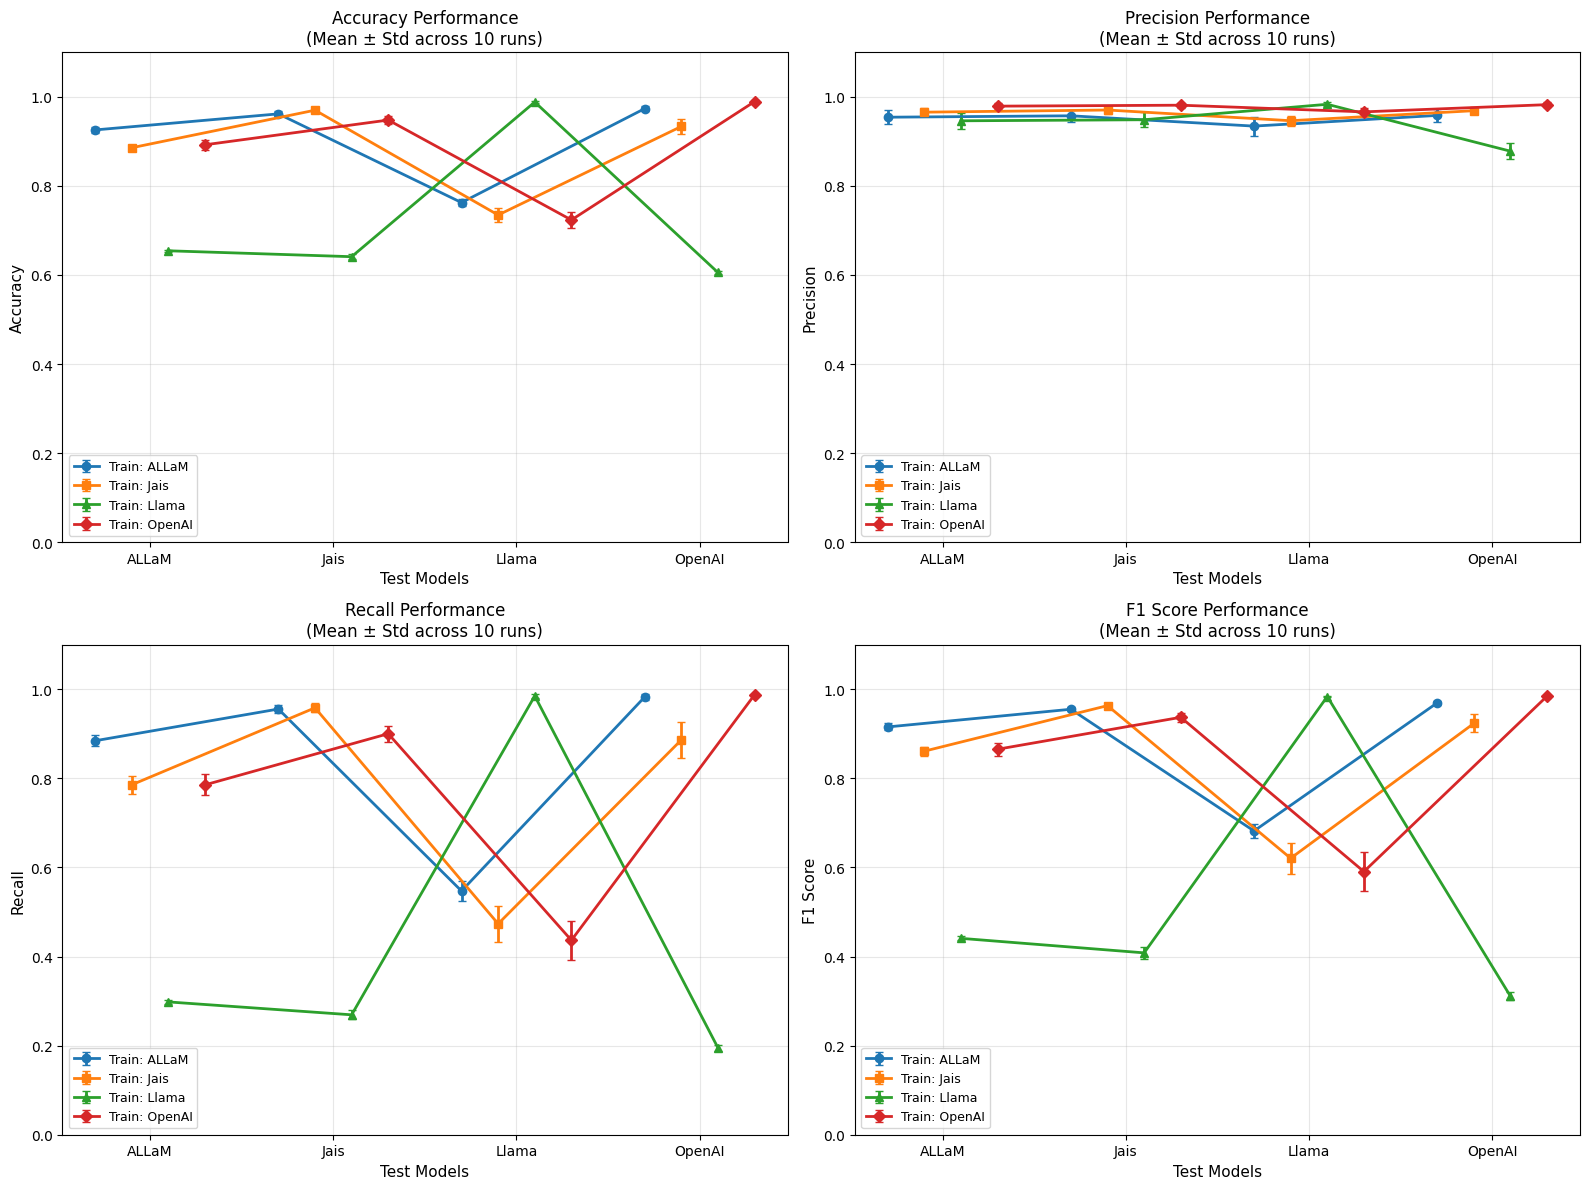


Performance graphs generated for all metrics across 10 runs.
Each point shows mean performance with error bars indicating ±1 standard deviation.


In [10]:
# Plot performance graphs
def plot_cross_model_performance():
    """Plot performance graphs for all metrics."""
    stats = experiment.calculate_statistics()
    
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    metric_titles = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    model_display_names = {
        'allam': 'ALLaM',
        'jais-batched': 'Jais',
        'llama-batched': 'Llama', 
        'openai': 'OpenAI'
    }
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    markers = ['o', 's', '^', 'D']
    
    for metric_idx, metric in enumerate(metrics):
        ax = axes[metric_idx]
        
        for train_idx, train_model in enumerate(experiment.train_models):
            if train_model in stats:
                test_means = []
                test_stds = []
                test_labels = []
                
                for test_model in experiment.test_models:
                    if test_model in stats[train_model]:
                        mean_val = stats[train_model][test_model].get(f'{metric}_mean', 0) / 100
                        std_val = stats[train_model][test_model].get(f'{metric}_std', 0) / 100
                        test_means.append(mean_val)
                        test_stds.append(std_val)
                        test_labels.append(model_display_names[test_model])
                
                if test_means:
                    x_positions = np.arange(len(test_labels)) + train_idx * 0.2
                    ax.errorbar(x_positions, test_means, yerr=test_stds,
                               label=f'Train: {model_display_names[train_model]}', 
                               color=colors[train_idx], marker=markers[train_idx],
                               linewidth=2, markersize=6, capsize=3, capthick=1)
        
        ax.set_xlabel('Test Models', fontsize=11)
        ax.set_ylabel(metric_titles[metric_idx], fontsize=11)
        ax.set_title(f'{metric_titles[metric_idx]} Performance\n(Mean ± Std across {experiment.num_runs} runs)', fontsize=12)
        ax.set_xticks(np.arange(len(experiment.test_models)) + 0.3)
        ax.set_xticklabels([model_display_names[model] for model in experiment.test_models])
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPerformance graphs generated for all metrics across {experiment.num_runs} runs.")
    print("Each point shows mean performance with error bars indicating ±1 standard deviation.")

# Generate the plots
plot_cross_model_performance()

In [11]:
# Show final results file location
print(f"\nFinal results saved to: {experiment.results_file}")
print(f"Results file size: {os.path.getsize(experiment.results_file) / 1024:.2f} KB")


Final results saved to: notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/cross_model_detection_results.json
Results file size: 43.08 KB
